
# Fold 1 EGNN Baseline for Inactive → Active Translation

This notebook evaluates a small EGNN baseline on the same Fold 1 split used by the FoldFlow experiments.
It reuses the existing inactive→active translation dataset and the cached ESM embeddings under `cache/esm_embeddings/`.

Important: the baseline centers each residue coordinate set per sample before training to reduce sensitivity to arbitrary rigid-body offsets. Evaluation still uses aligned RMSD, matching the repository's existing metric helpers.


In [18]:

import json
import math
import os
import random
import sys
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import seaborn as sns


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'training').is_dir() and (candidate / 'data').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate the repository root')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from kinase_data.translation import InactiveActiveTranslationDataset
from training.fold1_experiment import rmsd_from_coordinates, structure_ca_coordinates

try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **kwargs):
        return x

REPORT_ROOT = PROJECT_ROOT / 'reports' / 'fold1_egnn'
FIGURE_ROOT = PROJECT_ROOT / 'figures' / 'fold1_egnn'
CHECKPOINT_ROOT = PROJECT_ROOT / 'checkpoints' / 'fold1_egnn'
for path in (REPORT_ROOT, FIGURE_ROOT, CHECKPOINT_ROOT):
    path.mkdir(parents=True, exist_ok=True)

SEED = 7
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'

print('Project root:', PROJECT_ROOT)
print('Device:', DEVICE)
print('CUDA available:', torch.cuda.is_available())
print('AMP enabled:', USE_AMP)


def process_memory_mb() -> float:
    try:
        import psutil
        return float(psutil.Process(os.getpid()).memory_info().rss / 1e6)
    except Exception:
        import resource
        rss = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
        if sys.platform == 'darwin':
            return float(rss / (1024 * 1024))
        return float(rss / 1024)


def one_hot_aatype(aatype: torch.Tensor, num_classes: int = 21) -> torch.Tensor:
    return F.one_hot(aatype.clamp(min=0, max=num_classes - 1).long(), num_classes=num_classes).float()


def center_coordinates(coords: torch.Tensor, mask: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    valid = mask.bool()
    if valid.sum() == 0:
        centroid = coords.mean(dim=0, keepdim=True)
    else:
        centroid = coords[valid].mean(dim=0, keepdim=True)
    return coords - centroid, centroid


def structure_to_ca(structure: dict[str, torch.Tensor]) -> torch.Tensor:
    coords = torch.as_tensor(structure['rigids'], dtype=torch.float32)[..., 4:7]
    if coords.ndim == 3:
        coords = coords[0]
    return coords


def masked_mse(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    mask = mask.float().unsqueeze(-1)
    return ((pred - target).pow(2) * mask).sum() / mask.sum().clamp_min(1.0) / 3.0


def tensor_health(name: str, tensor: torch.Tensor) -> str:
    tensor = tensor.detach()
    finite = torch.isfinite(tensor)
    if tensor.numel() == 0:
        return f'{name}: empty'
    finite_ratio = float(finite.float().mean().item())
    if finite.any():
        finite_tensor = tensor[finite]
        min_val = float(finite_tensor.min().item())
        max_val = float(finite_tensor.max().item())
        mean_abs = float(finite_tensor.abs().mean().item())
    else:
        min_val = float('nan')
        max_val = float('nan')
        mean_abs = float('nan')
    return (
        f"{name}: shape={tuple(tensor.shape)} finite={finite_ratio:.4f} "
        f"min={min_val:.4f} max={max_val:.4f} mean|x|={mean_abs:.4f}"
    )


def report_batch_health(prefix: str, batch: dict[str, torch.Tensor]) -> None:
    print(f'[{prefix}] batch diagnostics')
    for key in ('coords_source', 'coords_target', 'esm', 'aa_one_hot', 'mask'):
        print('  ' + tensor_health(key, batch[key]))


def batch_rmsd_summary(pred_coords: np.ndarray, target_coords: np.ndarray) -> float:
    pred_coords = np.asarray(pred_coords, dtype=np.float64)
    target_coords = np.asarray(target_coords, dtype=np.float64)
    if pred_coords.size == 0 or target_coords.size == 0:
        return float('inf')
    if not np.isfinite(pred_coords).all() or not np.isfinite(target_coords).all():
        return float('inf')
    try:
        return float(rmsd_from_coordinates(target_coords, pred_coords))
    except Exception:
        centered_pred = pred_coords - pred_coords.mean(axis=0, keepdims=True)
        centered_target = target_coords - target_coords.mean(axis=0, keepdims=True)
        diff = centered_pred - centered_target
        return float(np.sqrt(np.mean(np.sum(diff * diff, axis=-1))))


def save_json(path: Path, payload: dict[str, Any]) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(payload, indent=2) + '\n', encoding='utf-8')


Project root: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada
Device: cpu
CUDA available: False
AMP enabled: False


In [19]:
# Load the exact Fold 1 split already used in the FoldFlow experiments.
train_ds = InactiveActiveTranslationDataset(fold_id=1, split='train', load_structures=True)
val_ds = InactiveActiveTranslationDataset(fold_id=1, split='validation', load_structures=True)
test_ds = InactiveActiveTranslationDataset(fold_id=1, split='test', load_structures=True)

print('Fold 1 sizes:')
print('  train:', len(train_ds))
print('  validation:', len(val_ds))
print('  test:', len(test_ds))


def dataset_summary(ds: InactiveActiveTranslationDataset, name: str) -> pd.DataFrame:
    rows = []
    for item in ds:
        source_coords = structure_to_ca(item['source_structure'])
        target_coords = structure_to_ca(item['target_structure'])
        rows.append({
            'split': name,
            'kinase': item['kinase'],
            'state': 'active',
            'residue_count': int(item['residue_count']),
            'sequence_identity': float(item['sequence_identity']),
            'rmsd_source_target': float(
                rmsd_from_coordinates(target_coords.cpu().numpy(), source_coords.cpu().numpy())
            ),
        })
    return pd.DataFrame(rows)


train_summary = dataset_summary(train_ds, 'train')
val_summary = dataset_summary(val_ds, 'validation')
test_summary = dataset_summary(test_ds, 'test')
summary_frame = pd.concat([train_summary, val_summary, test_summary], ignore_index=True)

kinase_table = summary_frame.groupby(['split', 'kinase']).size().unstack(fill_value=0)
state_table = summary_frame.groupby(['split']).size().to_frame('translation_pairs')
residue_table = summary_frame.groupby('split')['residue_count'].agg(['mean', 'min', 'max'])

print()
print('Kinase distribution:')
display(kinase_table)
print()
print('Translation pairs:')
display(state_table)
print()
print('Residue counts:')
display(residue_table)


Fold 1 sizes:
  train: 215
  validation: 90
  test: 101


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]



Kinase distribution:


kinase,ABL1,AKT1,ALK,BRAF,CDK4,CDK6,EGFR,ERBB2,FGFR1,KIT,MET,PDGFRA,PIK3CA
split,,,,,,,,,,,,,
test,0,0,0,0,0,0,101,0,0,0,0,0,0
train,35,17,3,0,11,14,0,3,2,22,95,9,4
validation,0,0,0,90,0,0,0,0,0,0,0,0,0



Translation pairs:


,translation_pairs
split,
test,101
train,215
validation,90



Residue counts:


,mean,min,max
split,,,
test,277.772277,255,316
train,284.553488,182,1039
validation,261.122222,226,281


## EGNN Model and Data Pipeline

In [20]:

@dataclass
class BaselineConfig:
    fold_id: int = 1
    hidden_dim: int = 128
    message_dim: int = 128
    num_layers: int = 4
    batch_size: int = 1
    max_epochs: int = 7
    patience: int = 5
    learning_rate: float = 1e-5
    weight_decay: float = 1e-4
    grad_clip: float = 0.5
    num_workers: int = 0
    coord_update_scale: float = 0.01
    delta_scale: float = 0.5
    debug_batches: bool = True
    stable_mode: bool = True
    debug_first_batches: int = 3
    debug_layer_stats: bool = False


CONFIG = BaselineConfig()
print(CONFIG)


class EGNGLayer(nn.Module):
    def __init__(self, hidden_dim: int, message_dim: int, coord_update_scale: float = 0.01):
        super().__init__()
        edge_in = hidden_dim * 2 + 1
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_in, message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, message_dim),
            nn.SiLU(),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(hidden_dim + message_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
        )
        self.coord_mlp = nn.Sequential(
            nn.Linear(edge_in, message_dim),
            nn.SiLU(),
            nn.Linear(message_dim, 1),
        )
        self.node_norm = nn.LayerNorm(hidden_dim)
        self.coord_update_scale = coord_update_scale

    def forward(self, h: torch.Tensor, x: torch.Tensor, mask: torch.Tensor, debug: bool = False, layer_idx: int | None = None) -> tuple[torch.Tensor, torch.Tensor]:
        bsz, nres, _ = x.shape
        pair_mask = mask[:, :, None] * mask[:, None, :]
        eye = torch.eye(nres, device=x.device, dtype=pair_mask.dtype).unsqueeze(0)
        pair_mask = pair_mask * (1.0 - eye)

        rel = x[:, :, None, :] - x[:, None, :, :]
        dist2 = rel.pow(2).sum(dim=-1, keepdim=True)
        hi = h[:, :, None, :].expand(-1, -1, nres, -1)
        hj = h[:, None, :, :].expand(-1, nres, -1, -1)
        edge_input = torch.cat([hi, hj, dist2], dim=-1)

        degree = pair_mask.sum(dim=2, keepdim=True).clamp_min(1.0)
        messages = self.edge_mlp(edge_input) * pair_mask.unsqueeze(-1)
        agg = messages.sum(dim=2) / degree
        h = self.node_norm(h + self.node_mlp(torch.cat([h, agg], dim=-1)))

        coord_weights = torch.tanh(self.coord_mlp(edge_input)) * pair_mask.unsqueeze(-1)
        coord_update = (coord_weights * rel).sum(dim=2) / degree
        x = x + self.coord_update_scale * coord_update
        x = x * mask.unsqueeze(-1)
        if debug:
            prefix = f'layer {layer_idx}' if layer_idx is not None else 'layer'
            print('  ', prefix, tensor_health('h', h), tensor_health('x', x), tensor_health('coord_update', coord_update))
        return h, x


class EGNNBaseline(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int = 128, message_dim: int = 128, num_layers: int = 4, aa_dim: int = 21, coord_update_scale: float = 0.01, delta_scale: float = 0.5):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.LayerNorm(input_dim + aa_dim),
            nn.Linear(input_dim + aa_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
        )
        self.layers = nn.ModuleList([EGNGLayer(hidden_dim, message_dim, coord_update_scale=coord_update_scale) for _ in range(num_layers)])
        self.out_mlp = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 3),
        )
        self.delta_scale = delta_scale

    def forward(self, coords: torch.Tensor, esm: torch.Tensor, aa_one_hot: torch.Tensor, mask: torch.Tensor, debug: bool = False) -> tuple[torch.Tensor, torch.Tensor]:
        x = torch.cat([esm, aa_one_hot], dim=-1)
        h = self.input_proj(x)
        for layer_idx, layer in enumerate(self.layers):
            h, coords = layer(h, coords, mask, debug=debug, layer_idx=layer_idx)
        delta = torch.tanh(self.out_mlp(h)) * self.delta_scale * mask.unsqueeze(-1)
        pred = coords + delta
        return pred, delta


class Fold1EgnnCollator:
    def __call__(self, samples: list[dict[str, Any]]) -> dict[str, Any]:
        max_len = max(int(sample['residue_count']) for sample in samples)
        bsz = len(samples)
        esm_dim = samples[0]['esm_embedding'].shape[-1]

        coords_source = torch.zeros(bsz, max_len, 3)
        coords_target = torch.zeros(bsz, max_len, 3)
        esm = torch.zeros(bsz, max_len, esm_dim)
        aa = torch.zeros(bsz, max_len, 21)
        mask = torch.zeros(bsz, max_len)
        metadata = []

        for i, sample in enumerate(samples):
            n = int(sample['residue_count'])
            source_coords = structure_to_ca(sample['source_structure']).float()
            target_coords = structure_to_ca(sample['target_structure']).float()
            source_coords, source_centroid = center_coordinates(source_coords, torch.ones(n))
            target_coords, target_centroid = center_coordinates(target_coords, torch.ones(n))
            coords_source[i, :n] = source_coords
            coords_target[i, :n] = target_coords
            esm[i, :n] = sample['esm_embedding'].float()
            aa[i, :n] = one_hot_aatype(sample['source_structure']['aatype'])
            mask[i, :n] = 1.0
            metadata.append({
                'kinase': sample['kinase'],
                'source_pdb_id': sample['source_pdb_id'],
                'target_pdb_id': sample['target_pdb_id'],
                'residue_count': n,
                'sequence_identity': float(sample['sequence_identity']),
                'source_centroid': source_centroid.squeeze(0).tolist(),
                'target_centroid': target_centroid.squeeze(0).tolist(),
            })

        return {
            'coords_source': coords_source,
            'coords_target': coords_target,
            'esm': esm,
            'aa_one_hot': aa,
            'mask': mask,
            'metadata': metadata,
        }


collate_fn = Fold1EgnnCollator()
pin_memory = DEVICE.type == 'cuda'
train_loader = DataLoader(train_ds, batch_size=CONFIG.batch_size, shuffle=True, num_workers=CONFIG.num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
val_loader = DataLoader(val_ds, batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=CONFIG.batch_size, shuffle=False, num_workers=CONFIG.num_workers, pin_memory=pin_memory, collate_fn=collate_fn)

model = EGNNBaseline(
    input_dim=train_ds[0]['esm_embedding'].shape[-1],
    hidden_dim=CONFIG.hidden_dim,
    message_dim=CONFIG.message_dim,
    num_layers=CONFIG.num_layers,
    coord_update_scale=CONFIG.coord_update_scale,
    delta_scale=CONFIG.delta_scale,
).to(DEVICE)

print('Stable mode:', CONFIG.stable_mode)
print('Learning rate:', CONFIG.learning_rate)
print('Grad clip:', CONFIG.grad_clip)
print('Coord update scale:', CONFIG.coord_update_scale)
print('Delta scale:', CONFIG.delta_scale)

print('Parameter count:', sum(p.numel() for p in model.parameters()))
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))
print('Memory before training (MB):', round(process_memory_mb(), 2))


BaselineConfig(fold_id=1, hidden_dim=128, message_dim=128, num_layers=4, batch_size=1, max_epochs=7, patience=5, learning_rate=1e-05, weight_decay=0.0001, grad_clip=0.5, num_workers=0, coord_update_scale=0.01, delta_scale=0.5, debug_batches=True, stable_mode=True, debug_first_batches=3, debug_layer_stats=False)
Stable mode: True
Learning rate: 1e-05
Grad clip: 0.5
Coord update scale: 0.01
Delta scale: 0.5
Parameter count: 732337
Trainable parameters: 732337
Memory before training (MB): 1265.63


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


## Training

In [21]:

optimizer = torch.optim.AdamW(model.parameters(), lr=CONFIG.learning_rate, weight_decay=CONFIG.weight_decay)
scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP) if DEVICE.type == 'cuda' else None


def run_epoch(loader: DataLoader, training: bool) -> dict[str, float]:
    if training:
        model.train()
    else:
        model.eval()
    total_loss = 0.0
    total_rmsd_source_target = 0.0
    total_rmsd_prediction_target = 0.0
    total_improvement = 0.0
    total_success = 0.0
    count = 0

    for batch in loader:
        coords_source = batch['coords_source'].to(DEVICE)
        coords_target = batch['coords_target'].to(DEVICE)
        esm = batch['esm'].to(DEVICE)
        aa = batch['aa_one_hot'].to(DEVICE)
        mask = batch['mask'].to(DEVICE)

        if count < CONFIG.debug_first_batches and CONFIG.debug_batches:
            report_batch_health('train' if training else 'validation', {
                'coords_source': coords_source,
                'coords_target': coords_target,
                'esm': esm,
                'aa_one_hot': aa,
                'mask': mask,
            })

        debug_forward = (not CONFIG.stable_mode) and CONFIG.debug_layer_stats and training and count < CONFIG.debug_first_batches
        with torch.amp.autocast('cuda', enabled=USE_AMP):
            pred_coords, delta = model(coords_source, esm, aa, mask, debug=debug_forward)
            loss = masked_mse(pred_coords, coords_target, mask)

        if not torch.isfinite(pred_coords).all() or not torch.isfinite(delta).all() or not torch.isfinite(loss):
            print('Non-finite detected in forward pass')
            print(tensor_health('coords_source', coords_source))
            print(tensor_health('coords_target', coords_target))
            print(tensor_health('esm', esm))
            print(tensor_health('aa_one_hot', aa))
            print(tensor_health('pred_coords', pred_coords))
            print(tensor_health('delta', delta))
            print(tensor_health('loss', loss))
            raise FloatingPointError('Non-finite values detected during EGNN forward/loss computation')

        if training:
            optimizer.zero_grad(set_to_none=True)
            if USE_AMP:
                assert scaler is not None
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG.grad_clip)
                optimizer.step()

            if training and count < CONFIG.debug_first_batches:
                print(f'    raw grad_norm={float(grad_norm):.6f} clipped_to={CONFIG.grad_clip:.3f}')

            if not math.isfinite(float(grad_norm)):
                raise FloatingPointError(f'Gradient norm became non-finite: {float(grad_norm)}')

        if training:
            print(f'  batch {count + 1:03d} loss={float(loss.detach().cpu()):.6f} grad_norm={float(grad_norm):.6f}')
        elif count < CONFIG.debug_first_batches and CONFIG.debug_batches:
            print(f'  batch {count + 1:03d} loss={float(loss.detach().cpu()):.6f}')
        total_loss += float(loss.detach().cpu())
        count += 1

        with torch.no_grad():
            for b in range(coords_source.shape[0]):
                n = int(mask[b].sum().item())
                source_np = coords_source[b, :n].detach().cpu().numpy()
                target_np = coords_target[b, :n].detach().cpu().numpy()
                pred_np = pred_coords[b, :n].detach().cpu().numpy()
                rmsd_source_target = batch_rmsd_summary(source_np, target_np)
                rmsd_prediction_target = batch_rmsd_summary(pred_np, target_np)
                improvement = rmsd_source_target - rmsd_prediction_target
                total_rmsd_source_target += rmsd_source_target
                total_rmsd_prediction_target += rmsd_prediction_target
                total_improvement += improvement
                total_success += float(improvement > 0.0)

    denom = max(1, count)
    return {
        'loss': total_loss / denom,
        'rmsd_source_target': total_rmsd_source_target / max(1, len(loader.dataset)),
        'rmsd_prediction_target': total_rmsd_prediction_target / max(1, len(loader.dataset)),
        'rmsd_improvement': total_improvement / max(1, len(loader.dataset)),
        'success_rate': total_success / max(1, len(loader.dataset)),
    }


def evaluate_with_predictions(loader: DataLoader, model_to_use: nn.Module) -> pd.DataFrame:
    model_to_use.eval()
    rows = []
    with torch.no_grad():
        for sample_index, batch in enumerate(loader):
            coords_source = batch['coords_source'].to(DEVICE)
            coords_target = batch['coords_target'].to(DEVICE)
            esm = batch['esm'].to(DEVICE)
            aa = batch['aa_one_hot'].to(DEVICE)
            mask = batch['mask'].to(DEVICE)
            pred_coords, delta = model_to_use(coords_source, esm, aa, mask)
            for b in range(coords_source.shape[0]):
                n = int(mask[b].sum().item())
                source_np = coords_source[b, :n].detach().cpu().numpy()
                target_np = coords_target[b, :n].detach().cpu().numpy()
                pred_np = pred_coords[b, :n].detach().cpu().numpy()
                row_meta = batch['metadata'][b]
                rmsd_source_target = batch_rmsd_summary(source_np, target_np)
                rmsd_prediction_target = batch_rmsd_summary(pred_np, target_np)
                rows.append({
                    'sample_index': sample_index * loader.batch_size + b,
                    'kinase': row_meta['kinase'],
                    'source_pdb_id': row_meta['source_pdb_id'],
                    'target_pdb_id': row_meta['target_pdb_id'],
                    'residue_count': row_meta['residue_count'],
                    'sequence_identity': row_meta['sequence_identity'],
                    'rmsd_source_target': rmsd_source_target,
                    'rmsd_prediction_target': rmsd_prediction_target,
                    'rmsd_improvement': rmsd_source_target - rmsd_prediction_target,
                    'successful_translation': rmsd_prediction_target < rmsd_source_target,
                    'source_coords': source_np.tolist(),
                    'prediction_coords': pred_np.tolist(),
                    'target_coords': target_np.tolist(),
                })
    return pd.DataFrame(rows)


history_rows = []
best_val_loss = float('inf')
best_epoch = 0
best_checkpoint = CHECKPOINT_ROOT / 'best.pt'
last_checkpoint = CHECKPOINT_ROOT / 'last.pt'
start_time = time.perf_counter()
patience_counter = 0
for epoch in tqdm(range(1, CONFIG.max_epochs + 1), desc='Training EGNN'):
    epoch_start = time.perf_counter()
    train_metrics = run_epoch(train_loader, training=True)
    val_metrics = run_epoch(val_loader, training=False)
    epoch_seconds = time.perf_counter() - epoch_start

    row = {
        'epoch': epoch,
        'train_loss': train_metrics['loss'],
        'validation_loss': val_metrics['loss'],
        'train_rmsd_source_target': train_metrics['rmsd_source_target'],
        'train_rmsd_prediction_target': train_metrics['rmsd_prediction_target'],
        'train_rmsd_improvement': train_metrics['rmsd_improvement'],
        'train_success_rate': train_metrics['success_rate'],
        'validation_rmsd_source_target': val_metrics['rmsd_source_target'],
        'validation_rmsd_prediction_target': val_metrics['rmsd_prediction_target'],
        'validation_rmsd_improvement': val_metrics['rmsd_improvement'],
        'validation_success_rate': val_metrics['success_rate'],
        'epoch_seconds': epoch_seconds,
    }
    history_rows.append(row)

    torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'config': CONFIG.__dict__}, last_checkpoint)
    if val_metrics['loss'] < best_val_loss:
        best_val_loss = val_metrics['loss']
        best_epoch = epoch
        patience_counter = 0
        torch.save({'epoch': epoch, 'model_state': model.state_dict(), 'optimizer_state': optimizer.state_dict(), 'config': CONFIG.__dict__}, best_checkpoint)
    else:
        patience_counter += 1

    print(
        f"Epoch {epoch:03d} | "
        f"train loss {train_metrics['loss']:.4f} | val loss {val_metrics['loss']:.4f} | "
        f"val RMSD {val_metrics['rmsd_prediction_target']:.3f} | val improv {val_metrics['rmsd_improvement']:.3f} | "
        f"{epoch_seconds:.1f}s"
    )

    if patience_counter >= CONFIG.patience:
        print(f'Early stopping at epoch {epoch} (best epoch {best_epoch})')
        break

training_seconds = time.perf_counter() - start_time
history = pd.DataFrame(history_rows)
metrics_path = REPORT_ROOT / 'training_history.csv'
history.to_csv(metrics_path, index=False)
print('Training time (s):', round(training_seconds, 2))
print('Best epoch:', best_epoch)
print('Best validation loss:', round(best_val_loss, 6))
print('Last checkpoint:', last_checkpoint)
print('Best checkpoint:', best_checkpoint)


Training EGNN:   0%|          | 0/7 [00:00<?, ?it/s]

[train] batch diagnostics
  coords_source: shape=(1, 286, 3) finite=1.0000 min=-27.5074 max=26.9306 mean|x|=9.2759
  coords_target: shape=(1, 286, 3) finite=1.0000 min=-28.5670 max=28.7940 mean|x|=9.0464
  esm: shape=(1, 286, 1280) finite=1.0000 min=-8.6353 max=3.2821 mean|x|=0.1745
  aa_one_hot: shape=(1, 286, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask: shape=(1, 286) finite=1.0000 min=1.0000 max=1.0000 mean|x|=1.0000
    raw grad_norm=1.759476 clipped_to=0.500
  batch 001 loss=10.291587 grad_norm=1.759476
[train] batch diagnostics
  coords_source: shape=(1, 253, 3) finite=1.0000 min=-26.5032 max=26.2235 mean|x|=8.9650
  coords_target: shape=(1, 253, 3) finite=1.0000 min=-26.7772 max=29.3767 mean|x|=8.9528
  esm: shape=(1, 253, 1280) finite=1.0000 min=-8.2769 max=2.7841 mean|x|=0.1626
  aa_one_hot: shape=(1, 253, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask: shape=(1, 253) finite=1.0000 min=1.0000 max=1.0000 mean|x|=1.0000
    raw grad_norm=0.640550

Training EGNN:  14%|█▍        | 1/7 [03:12<19:16, 192.83s/it]

Epoch 001 | train loss 7.9627 | val loss 7.1926 | val RMSD 3.097 | val improv -0.020 | 192.8s
[train] batch diagnostics
  coords_source: shape=(1, 298, 3) finite=1.0000 min=-28.5205 max=29.2625 mean|x|=9.3069
  coords_target: shape=(1, 298, 3) finite=1.0000 min=-28.4217 max=28.9393 mean|x|=9.2107
  esm: shape=(1, 298, 1280) finite=1.0000 min=-8.5686 max=3.3061 mean|x|=0.1743
  aa_one_hot: shape=(1, 298, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask: shape=(1, 298) finite=1.0000 min=1.0000 max=1.0000 mean|x|=1.0000
    raw grad_norm=9.518985 clipped_to=0.500
  batch 001 loss=8.456686 grad_norm=9.518985
[train] batch diagnostics
  coords_source: shape=(1, 266, 3) finite=1.0000 min=-24.8521 max=26.8869 mean|x|=9.0026
  coords_target: shape=(1, 266, 3) finite=1.0000 min=-25.3300 max=26.5690 mean|x|=8.9385
  esm: shape=(1, 266, 1280) finite=1.0000 min=-8.3609 max=3.0020 mean|x|=0.1774
  aa_one_hot: shape=(1, 266, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask:

Training EGNN:  29%|██▊       | 2/7 [06:19<15:44, 188.97s/it]

...

Epoch 005 | train loss 7.2795 | val loss 7.1379 | val RMSD 3.070 | val improv 0.008 | 197.2s
[train] batch diagnostics
  coords_source: shape=(1, 269, 3) finite=1.0000 min=-25.5441 max=24.8699 mean|x|=9.0078
  coords_target: shape=(1, 269, 3) finite=1.0000 min=-26.5781 max=25.5699 mean|x|=8.8148
  esm: shape=(1, 269, 1280) finite=1.0000 min=-8.1569 max=3.3211 mean|x|=0.1748
  aa_one_hot: shape=(1, 269, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask: shape=(1, 269) finite=1.0000 min=1.0000 max=1.0000 mean|x|=1.0000
    raw grad_norm=17.764639 clipped_to=0.500
  batch 001 loss=8.408978 grad_norm=17.764639
[train] batch diagnostics
  coords_source: shape=(1, 250, 3) finite=1.0000 min=-25.6378 max=27.2032 mean|x|=8.8486
  coords_target: shape=(1, 250, 3) finite=1.0000 min=-22.8906 max=26.9668 mean|x|=8.8200
  esm: shape=(1, 250, 1280) finite=1.0000 min=-8.3179 max=2.9657 mean|x|=0.1778
  aa_one_hot: shape=(1, 250, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask

Training EGNN:  86%|████████▌ | 6/7 [19:21<03:15, 195.12s/it]

Epoch 006 | train loss 7.2202 | val loss 7.1057 | val RMSD 3.063 | val improv 0.014 | 196.8s
[train] batch diagnostics
  coords_source: shape=(1, 277, 3) finite=1.0000 min=-28.5358 max=26.5502 mean|x|=9.0596
  coords_target: shape=(1, 277, 3) finite=1.0000 min=-27.6852 max=26.6608 mean|x|=8.9532
  esm: shape=(1, 277, 1280) finite=1.0000 min=-7.9617 max=3.3864 mean|x|=0.1794
  aa_one_hot: shape=(1, 277, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask: shape=(1, 277) finite=1.0000 min=1.0000 max=1.0000 mean|x|=1.0000
    raw grad_norm=22.194349 clipped_to=0.500
  batch 001 loss=8.041087 grad_norm=22.194349
[train] batch diagnostics
  coords_source: shape=(1, 243, 3) finite=1.0000 min=-23.7918 max=29.0462 mean|x|=8.7594
  coords_target: shape=(1, 243, 3) finite=1.0000 min=-25.0006 max=30.8354 mean|x|=8.5609
  esm: shape=(1, 243, 1280) finite=1.0000 min=-8.4407 max=3.1905 mean|x|=0.1738
  aa_one_hot: shape=(1, 243, 21) finite=1.0000 min=0.0000 max=1.0000 mean|x|=0.0476
  mask

Training EGNN: 100%|██████████| 7/7 [22:34<00:00, 193.46s/it]

Epoch 007 | train loss 7.1678 | val loss 7.1544 | val RMSD 3.060 | val improv 0.018 | 192.7s
Training time (s): 1354.32
Best epoch: 6
Best validation loss: 7.105675
Last checkpoint: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/checkpoints/fold1_egnn/last.pt
Best checkpoint: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/checkpoints/fold1_egnn/best.pt


## Curves and Diagnostic Plots

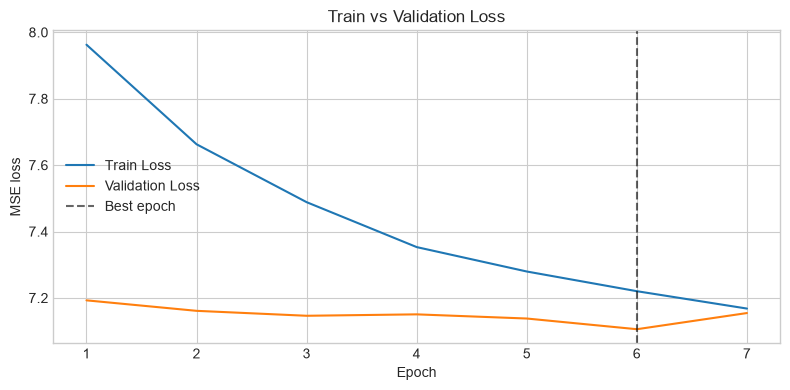

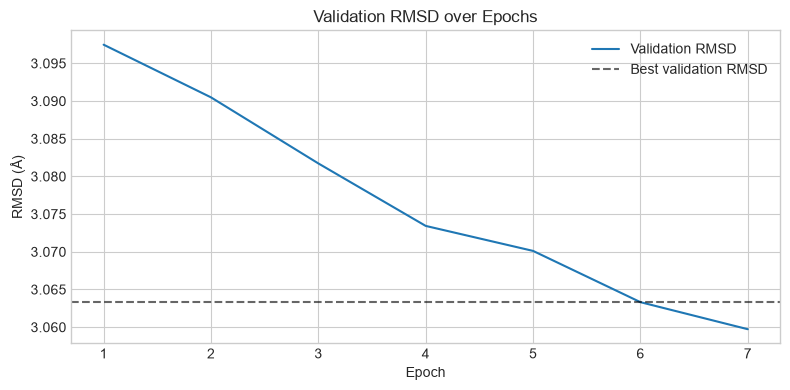

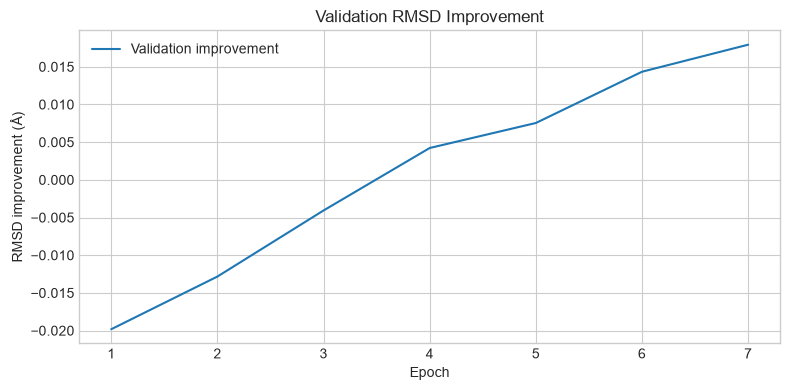

In [22]:

plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['epoch'], history['train_loss'], label='Train Loss')
ax.plot(history['epoch'], history['validation_loss'], label='Validation Loss')
ax.axvline(best_epoch, color='black', linestyle='--', alpha=0.6, label='Best epoch')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE loss')
ax.set_title('Train vs Validation Loss')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'train_validation_losses.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['epoch'], history['validation_rmsd_prediction_target'], label='Validation RMSD')
ax.axhline(history['validation_rmsd_prediction_target'].iloc[best_epoch - 1], color='black', linestyle='--', alpha=0.6, label='Best validation RMSD')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSD (Å)')
ax.set_title('Validation RMSD over Epochs')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'validation_rmsd.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history['epoch'], history['validation_rmsd_improvement'], label='Validation improvement')
ax.set_xlabel('Epoch')
ax.set_ylabel('RMSD improvement (Å)')
ax.set_title('Validation RMSD Improvement')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'validation_improvement.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)


## Evaluation: Identity Baseline vs EGNN

In [23]:

def summarize_metrics(frame: pd.DataFrame, label: str) -> dict[str, Any]:
    improvement = frame['rmsd_improvement']
    return {
        'method': label,
        'n_samples': int(len(frame)),
        'mean_rmsd_source_target': float(frame['rmsd_source_target'].mean()),
        'mean_rmsd_prediction_target': float(frame['rmsd_prediction_target'].mean()),
        'mean_rmsd_improvement': float(improvement.mean()),
        'median_rmsd_improvement': float(improvement.median()),
        'success_rate': float(frame['successful_translation'].mean()),
    }


def evaluate_identity(ds: InactiveActiveTranslationDataset, split_name: str) -> pd.DataFrame:
    rows = []
    for sample_index, sample in enumerate(ds):
        source_coords = structure_to_ca(sample['source_structure']).numpy()
        target_coords = structure_to_ca(sample['target_structure']).numpy()
        rmsd_source_target = rmsd_from_coordinates(target_coords, source_coords)
        rows.append({
            'sample_index': sample_index,
            'split': split_name,
            'kinase': sample['kinase'],
            'source_pdb_id': sample['source_pdb_id'],
            'target_pdb_id': sample['target_pdb_id'],
            'residue_count': int(sample['residue_count']),
            'sequence_identity': float(sample['sequence_identity']),
            'rmsd_source_target': rmsd_source_target,
            'rmsd_prediction_target': rmsd_source_target,
            'rmsd_improvement': 0.0,
            'successful_translation': False,
                    })
    return pd.DataFrame(rows)


identity_train = evaluate_identity(train_ds, 'train')
identity_val = evaluate_identity(val_ds, 'validation')
identity_test = evaluate_identity(test_ds, 'test')

# Load the best checkpoint before final evaluation.
best_payload = torch.load(best_checkpoint, map_location=DEVICE)
model.load_state_dict(best_payload['model_state'])

train_pred = evaluate_with_predictions(train_loader, model)
val_pred = evaluate_with_predictions(val_loader, model)
test_pred = evaluate_with_predictions(test_loader, model)

for frame, split in ((train_pred, 'train'), (val_pred, 'validation'), (test_pred, 'test')):
    frame['split'] = split

all_predictions = pd.concat([train_pred, val_pred, test_pred], ignore_index=True)
all_identity = pd.concat([identity_train, identity_val, identity_test], ignore_index=True)

train_summary_row = summarize_metrics(train_pred, 'EGNN train')
val_summary_row = summarize_metrics(val_pred, 'EGNN validation')
test_summary_row = summarize_metrics(test_pred, 'EGNN test')
identity_test_summary = summarize_metrics(identity_test, 'Identity test')

comparison_table = pd.DataFrame([
    {
        'Method': 'Identity',
        'RMSD pred→target (Å)': identity_test_summary['mean_rmsd_prediction_target'],
        'Improvement (Å)': identity_test_summary['mean_rmsd_improvement'],
        'Success Rate': identity_test_summary['success_rate'],
    },
    {
        'Method': 'EGNN',
        'RMSD pred→target (Å)': test_summary_row['mean_rmsd_prediction_target'],
        'Improvement (Å)': test_summary_row['mean_rmsd_improvement'],
        'Success Rate': test_summary_row['success_rate'],
    },
])

display(comparison_table)

split_comparison = pd.DataFrame([train_summary_row, val_summary_row, test_summary_row])
display(split_comparison)

# FoldFlow comparison from the existing repository report.
foldflow_report_path = PROJECT_ROOT / 'reports' / 'fold1' / 'failure_modes' / 'fold1_failure_modes_report.json'
foldflow_report = json.loads(foldflow_report_path.read_text())
foldflow_cond_rmsd = float(foldflow_report['comparisons']['conditional_summary']['mean_rmsd_prediction_target'])
foldflow_identity_rmsd = float(foldflow_report['comparisons']['identity_summary']['mean_rmsd_prediction_target'])

EGNN_vs_Identity = identity_test_summary['mean_rmsd_prediction_target'] - test_summary_row['mean_rmsd_prediction_target']
EGNN_vs_FoldFlow = foldflow_cond_rmsd - test_summary_row['mean_rmsd_prediction_target']

print(f"FoldFlow condicionado: RMSD ≈ {foldflow_cond_rmsd:.3f} Å")
print(f"Identity baseline: RMSD ≈ {foldflow_identity_rmsd:.3f} Å")
print(f"EGNN: RMSD ≈ {test_summary_row['mean_rmsd_prediction_target']:.3f} Å")
print(f"EGNN_vs_Identity: {EGNN_vs_Identity:.3f} Å")
print(f"EGNN_vs_FoldFlow: {EGNN_vs_FoldFlow:.3f} Å")


/Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/third_party/foldflow_official/openfold/utils/tensor_utils.py:74: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/python_variable_indexing.cpp:312.)
  return data[ranges]


,Method,RMSD pred→target (Å),Improvement (Å),Success Rate
0,Identity,3.316142,0.000000,0.000000
1,EGNN,3.334170,-0.018028,0.554455


,method,n_samples,mean_rmsd_source_target,mean_rmsd_prediction_target,mean_rmsd_improvement,median_rmsd_improvement,success_rate
0,EGNN train,215,4.034038,3.887374,0.146664,0.222488,0.846512
1,EGNN validation,90,3.077655,3.063317,0.014337,0.058786,0.588889
2,EGNN test,101,3.316142,3.334170,-0.018028,0.011181,0.554455


FoldFlow condicionado: RMSD ≈ 16.706 Å
Identity baseline: RMSD ≈ 3.316 Å
EGNN: RMSD ≈ 3.334 Å
EGNN_vs_Identity: -0.018 Å
EGNN_vs_FoldFlow: 13.372 Å


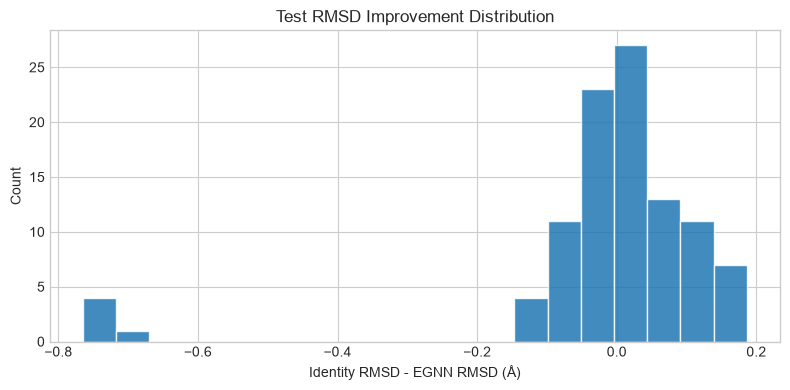

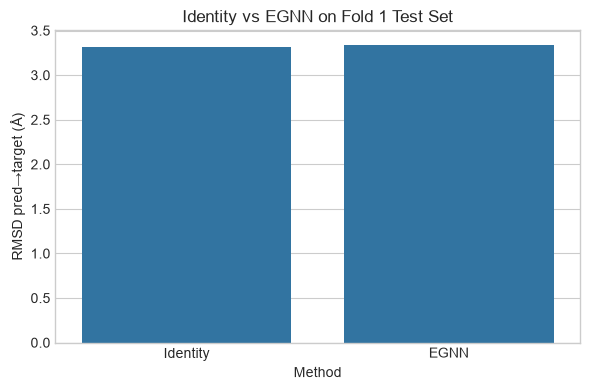

In [24]:

# Save metrics and plots.
train_pred.to_csv(REPORT_ROOT / 'train_metrics.csv', index=False)
val_pred.to_csv(REPORT_ROOT / 'validation_metrics.csv', index=False)
test_pred.to_csv(REPORT_ROOT / 'test_metrics.csv', index=False)
identity_test.to_csv(REPORT_ROOT / 'identity_test_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_pred['rmsd_improvement'], bins=20, color='#1f77b4', alpha=0.85, edgecolor='white')
ax.set_title('Test RMSD Improvement Distribution')
ax.set_xlabel('Identity RMSD - EGNN RMSD (Å)')
ax.set_ylabel('Count')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'test_rmsd_improvement_hist.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=comparison_table, x='Method', y='RMSD pred→target (Å)', ax=ax)
ax.set_title('Identity vs EGNN on Fold 1 Test Set')
fig.tight_layout()
fig.savefig(FIGURE_ROOT / 'identity_vs_egnn_bar.png', dpi=180, bbox_inches='tight')
plt.show()
plt.close(fig)


## Structural Visualizations

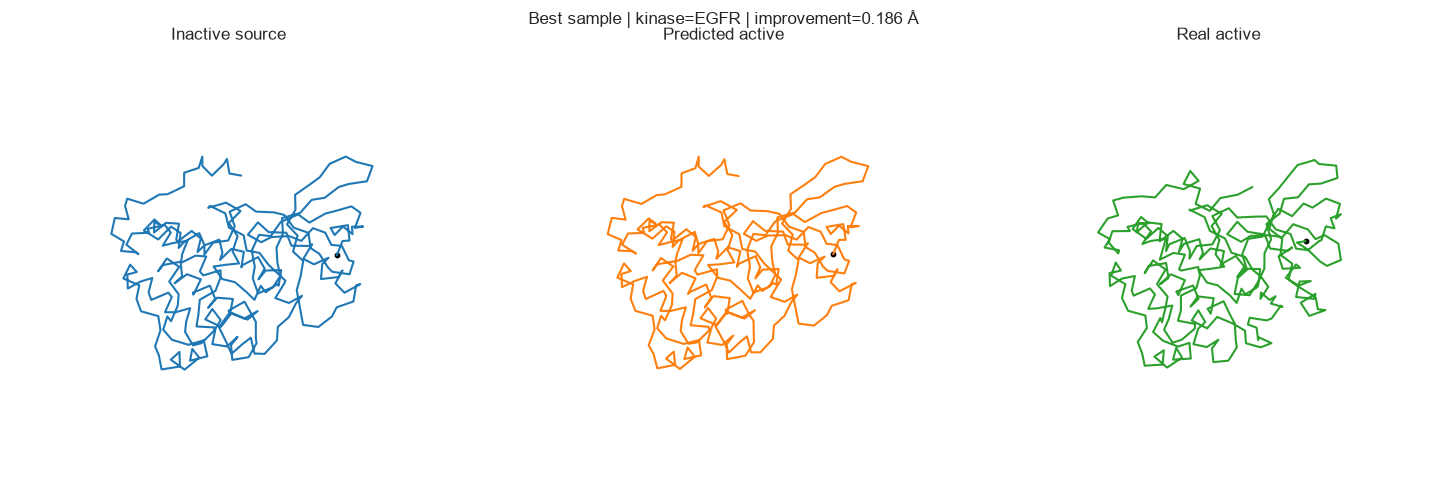

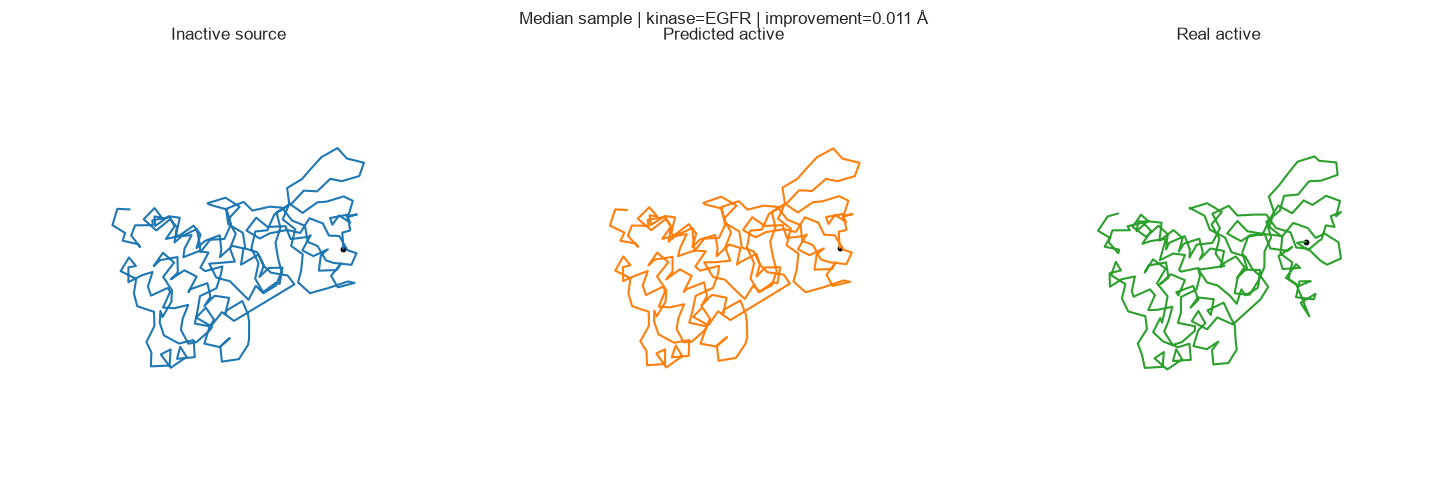

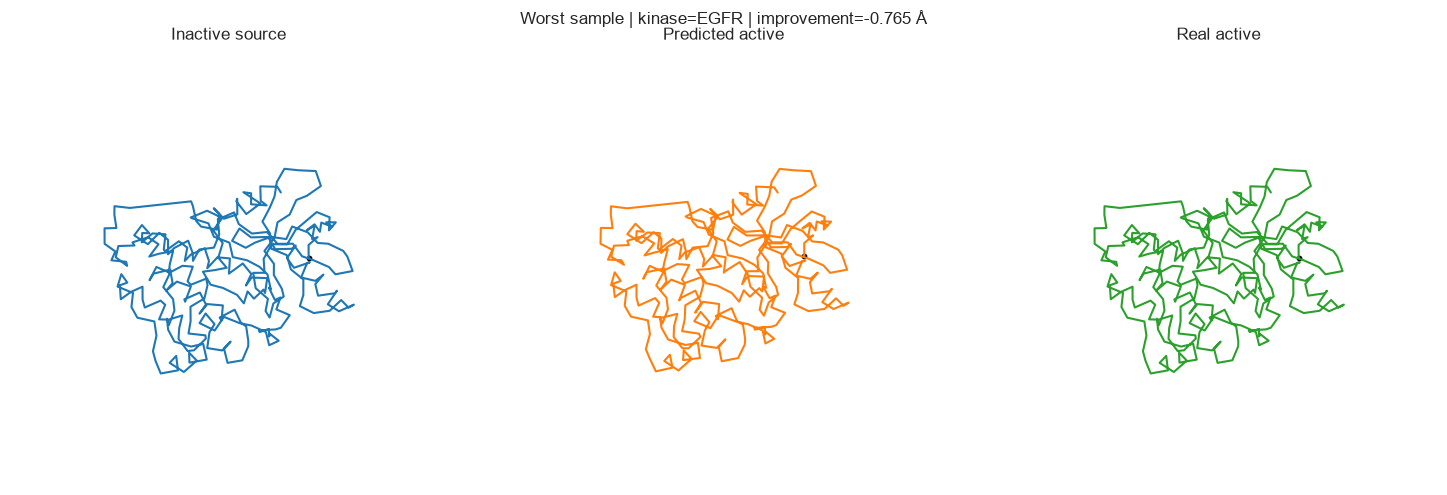

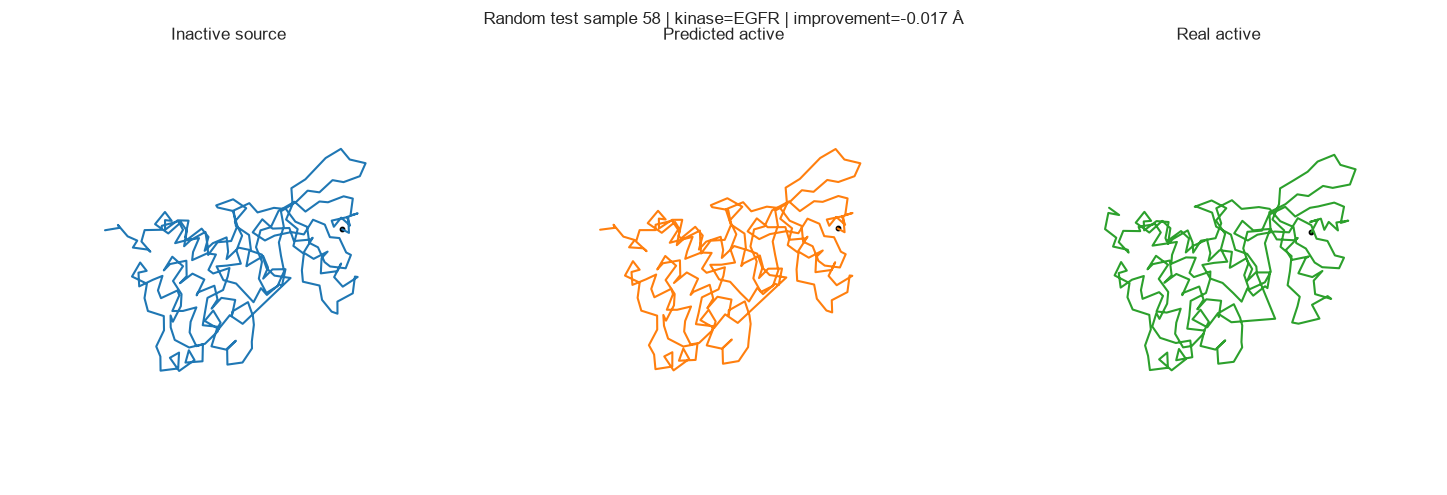

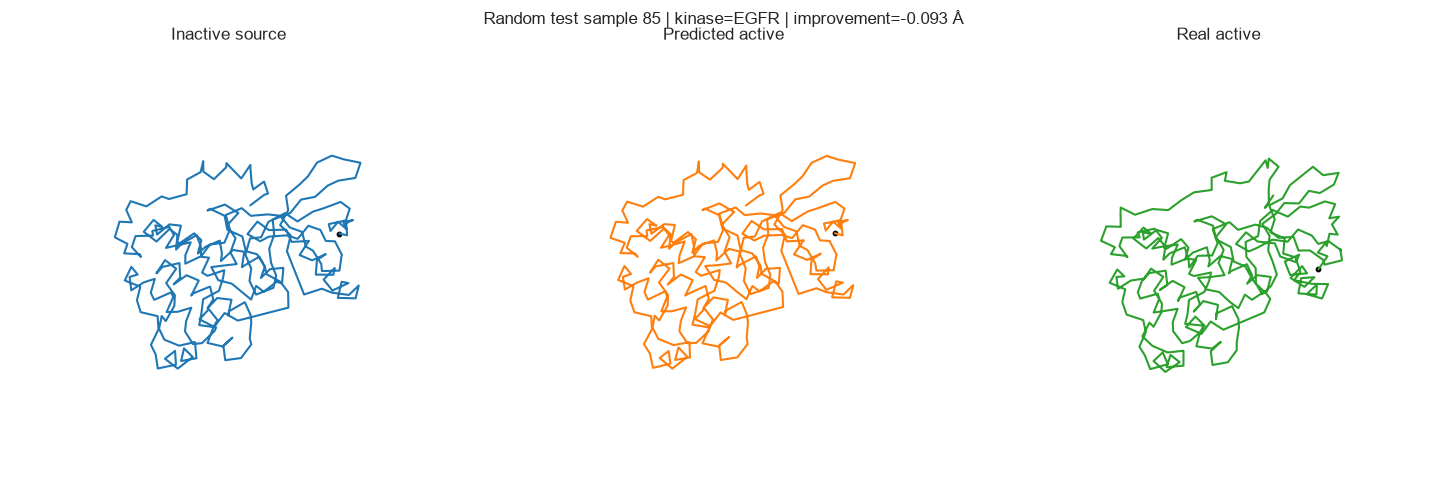

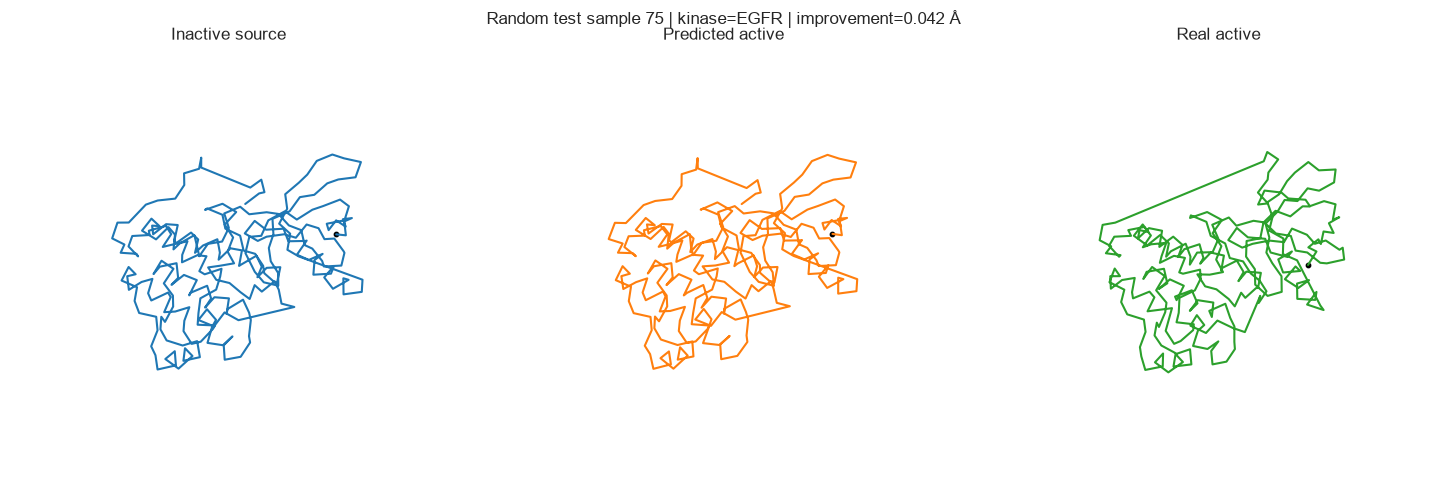

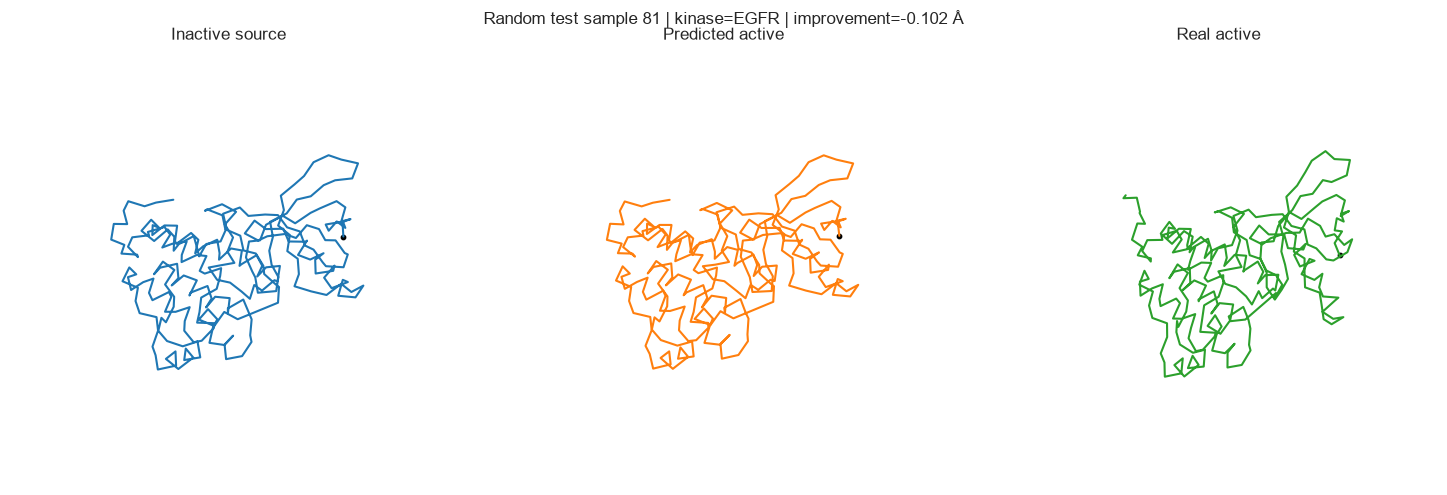

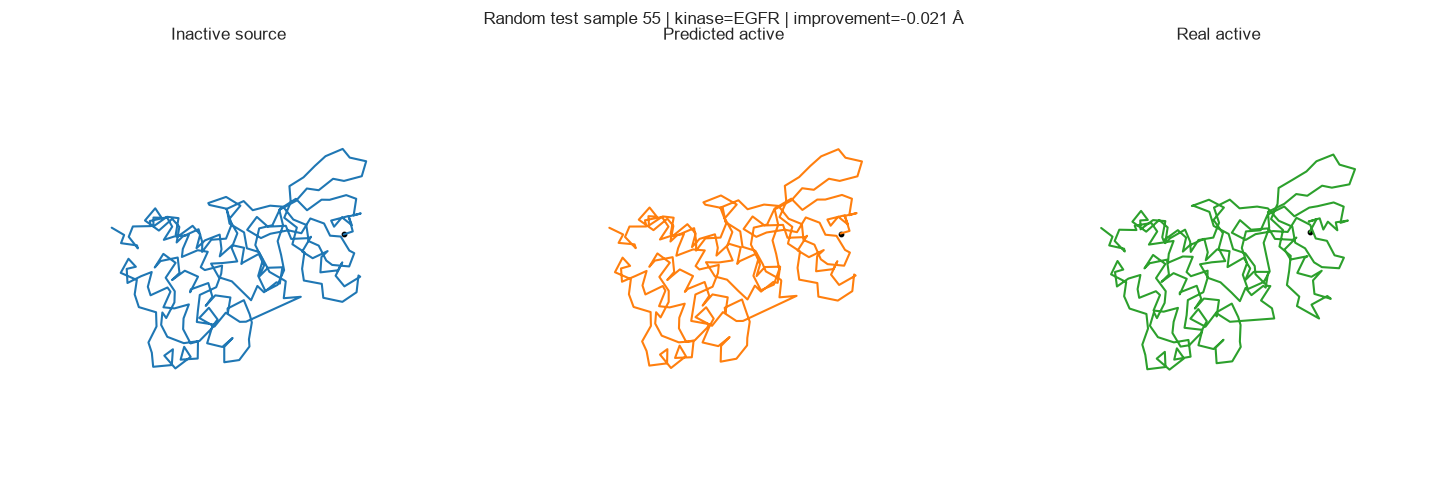

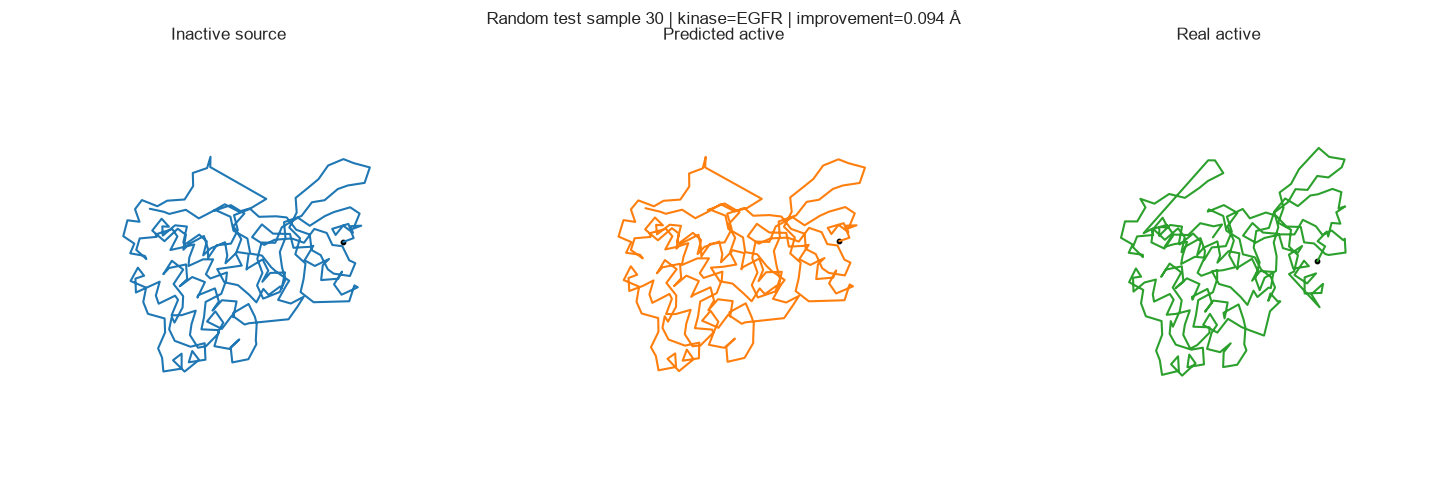

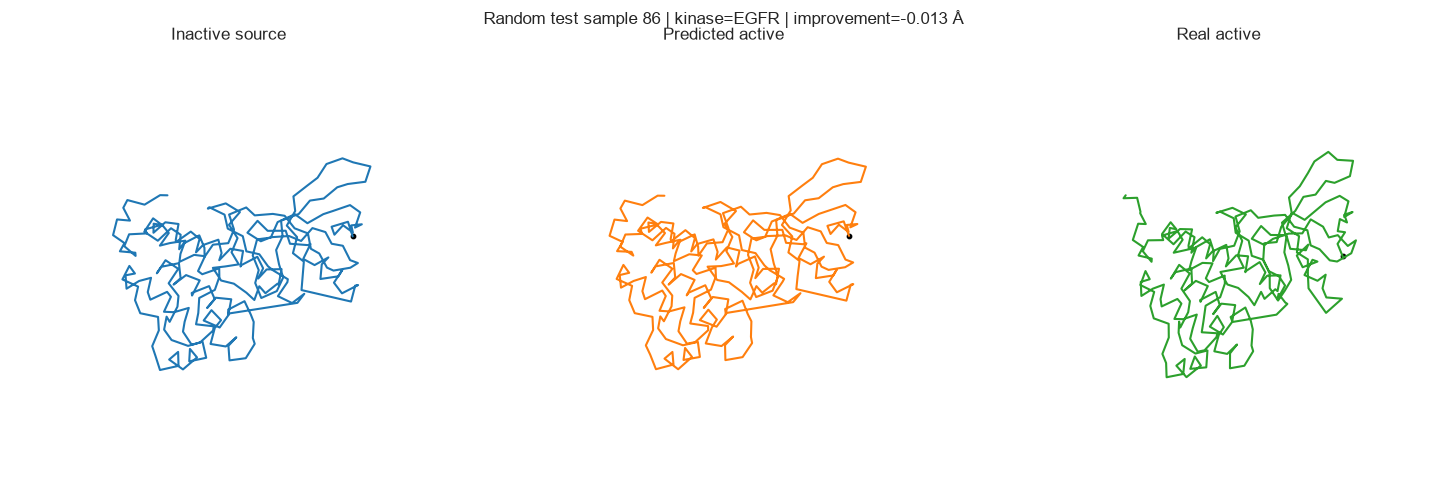

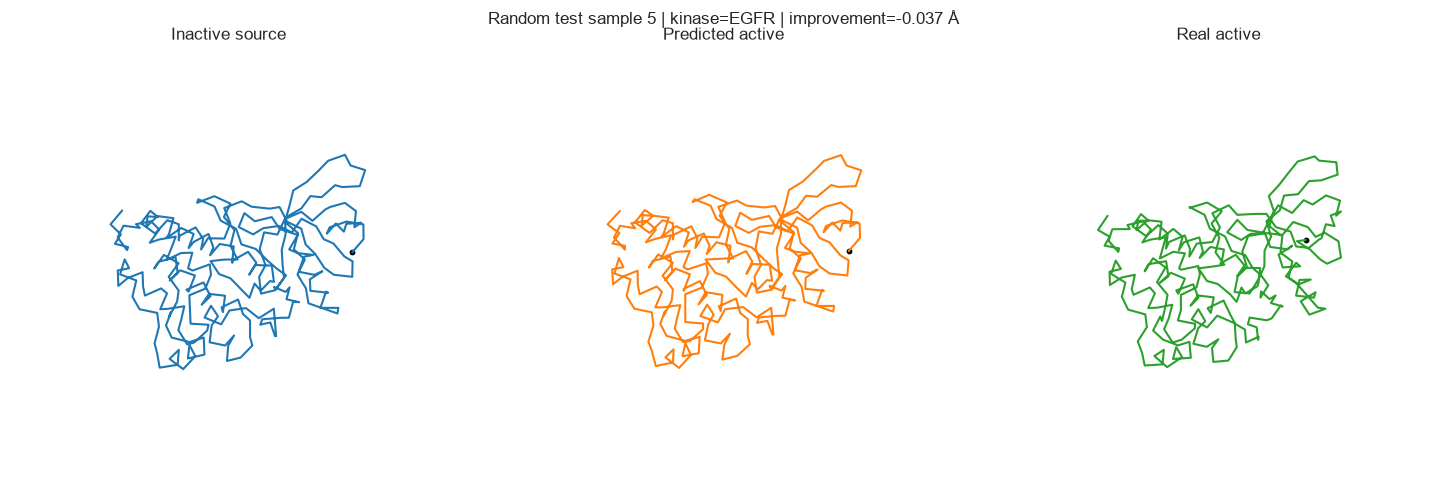

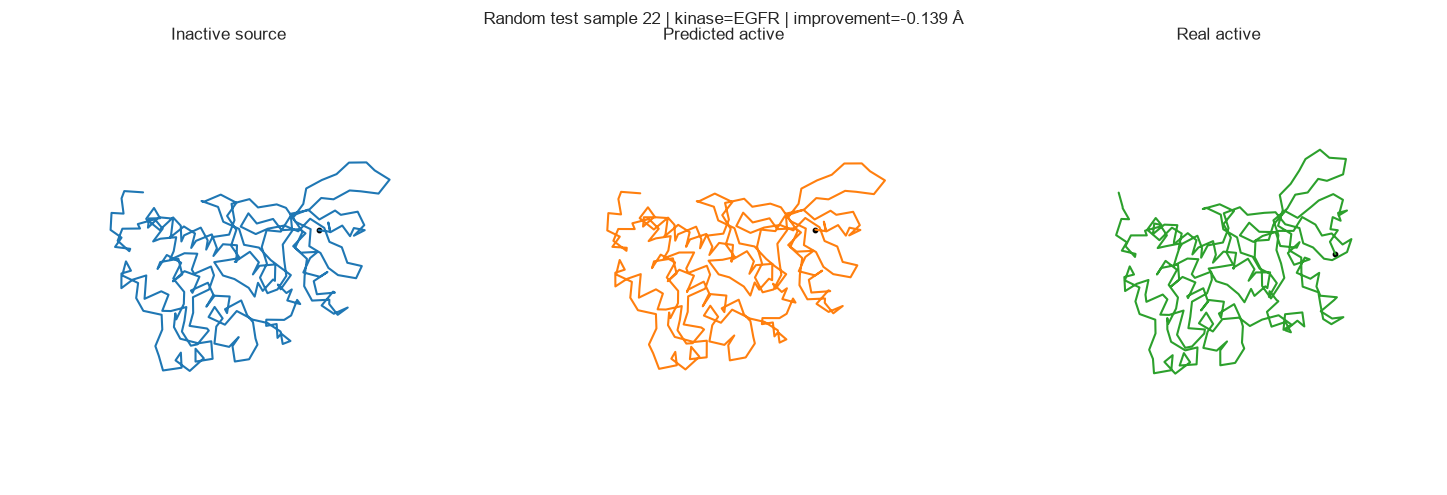

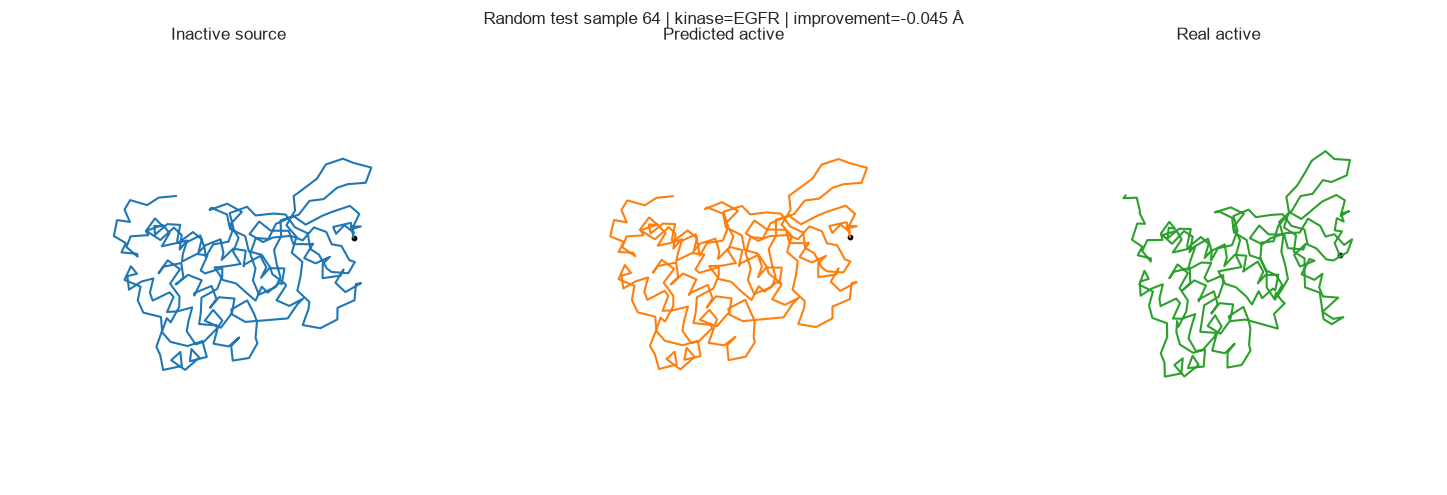

In [25]:

def plot_triptych(source_coords: np.ndarray, pred_coords: np.ndarray, target_coords: np.ndarray, title: str, output_path: Path) -> Path:
    fig = plt.figure(figsize=(15, 5))
    axes = [fig.add_subplot(1, 3, i + 1, projection='3d') for i in range(3)]
    payloads = [
        ('Inactive source', source_coords, '#1f77b4'),
        ('Predicted active', pred_coords, '#ff7f0e'),
        ('Real active', target_coords, '#2ca02c'),
    ]
    for ax, (label, coords, color) in zip(axes, payloads):
        ax.plot(coords[:, 0], coords[:, 1], coords[:, 2], color=color, lw=1.5)
        ax.scatter(coords[0, 0], coords[0, 1], coords[0, 2], color='black', s=10)
        ax.set_title(label)
        ax.set_axis_off()
    fig.suptitle(title)
    fig.tight_layout()
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return output_path


sorted_test = test_pred.sort_values('rmsd_improvement', ascending=False).reset_index(drop=True)
selected_examples = {
    'best': sorted_test.iloc[0],
    'median': sorted_test.iloc[len(sorted_test) // 2],
    'worst': sorted_test.iloc[-1],
}

example_dir = FIGURE_ROOT / 'examples'
example_dir.mkdir(parents=True, exist_ok=True)
for name, row in selected_examples.items():
    source_coords = np.asarray(row['source_coords'], dtype=np.float64)
    pred_coords = np.asarray(row['prediction_coords'], dtype=np.float64)
    target_coords = np.asarray(row['target_coords'], dtype=np.float64)
    plot_triptych(
        source_coords,
        pred_coords,
        target_coords,
        title=f"{name.title()} sample | kinase={row['kinase']} | improvement={row['rmsd_improvement']:.3f} Å",
        output_path=example_dir / f'{name}_sample.png',
    )

# Ten random test examples.
random_dir = example_dir / 'random_10'
random_dir.mkdir(parents=True, exist_ok=True)
random_state = np.random.default_rng(SEED)
random_indices = random_state.choice(len(test_pred), size=min(10, len(test_pred)), replace=False)
for index in random_indices:
    row = test_pred.iloc[int(index)]
    plot_triptych(
        np.asarray(row['source_coords'], dtype=np.float64),
        np.asarray(row['prediction_coords'], dtype=np.float64),
        np.asarray(row['target_coords'], dtype=np.float64),
        title=f"Random test sample {int(index)} | kinase={row['kinase']} | improvement={row['rmsd_improvement']:.3f} Å",
        output_path=random_dir / f'sample_{int(index):03d}.png',
    )


## Final Report

In [26]:
final_report = {
    'fold_id': CONFIG.fold_id,
    'dataset_sizes': {
        'train': len(train_ds),
        'validation': len(val_ds),
        'test': len(test_ds),
    },
    'average_residue_count': {
        'train': float(train_summary['residue_count'].mean()),
        'validation': float(val_summary['residue_count'].mean()),
        'test': float(test_summary['residue_count'].mean()),
    },
    'hyperparameters': CONFIG.__dict__,
    'parameter_count': int(sum(p.numel() for p in model.parameters())),
    'trainable_parameters': int(sum(p.numel() for p in model.parameters() if p.requires_grad)),
    'best_epoch': int(best_epoch),
    'best_validation_loss': float(best_val_loss),
    'final_train_loss': float(history['train_loss'].iloc[-1]),
    'final_validation_loss': float(history['validation_loss'].iloc[-1]),
    'identity_test_rmsd': float(identity_test_summary['mean_rmsd_prediction_target']),
    'egnn_test_rmsd': float(test_summary_row['mean_rmsd_prediction_target']),
    'rmsd_improvement': float(EGNN_vs_Identity),
    'success_rate': float(test_summary_row['success_rate']),
    'foldflow_conditional_rmsd': float(foldflow_cond_rmsd),
    'foldflow_identity_rmsd': float(foldflow_identity_rmsd),
    'egnn_vs_identity': float(EGNN_vs_Identity),
    'egnn_vs_foldflow': float(EGNN_vs_FoldFlow),
    'training_seconds': float(training_seconds),
    'memory_mb': float(process_memory_mb()),
    'report_root': str(REPORT_ROOT),
    'figure_root': str(FIGURE_ROOT),
    'checkpoint_best': str(best_checkpoint),
    'checkpoint_last': str(last_checkpoint),
    'training_history_csv': str(metrics_path),
    'test_metrics_csv': str(REPORT_ROOT / 'test_metrics.csv'),
}

save_json(REPORT_ROOT / 'egnn_results.json', final_report)

summary_table = pd.DataFrame([
    {
        'Metric': 'FoldFlow conditioned RMSD',
        'Value': foldflow_cond_rmsd,
    },
    {
        'Metric': 'Identity baseline RMSD',
        'Value': foldflow_identity_rmsd,
    },
    {
        'Metric': 'EGNN RMSD',
        'Value': test_summary_row['mean_rmsd_prediction_target'],
    },
    {
        'Metric': 'EGNN vs Identity',
        'Value': EGNN_vs_Identity,
    },
    {
        'Metric': 'EGNN vs FoldFlow',
        'Value': EGNN_vs_FoldFlow,
    },
])

display(summary_table)
print()
print('Final report written to:', REPORT_ROOT / 'egnn_results.json')
print('Training time (s):', round(training_seconds, 2))
print('Peak / current memory (MB):', round(process_memory_mb(), 2))


,Metric,Value
0,FoldFlow conditioned RMSD,16.706137
1,Identity baseline RMSD,3.316142
2,EGNN RMSD,3.334170
3,EGNN vs Identity,-0.018028
4,EGNN vs FoldFlow,13.371967



Final report written to: /Users/josefinadehan/tp_vision_avanzada/TPF_Vision_Avanzada/reports/fold1_egnn/egnn_results.json
Training time (s): 1354.32
Peak / current memory (MB): 1492.89
